In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')
import matplotlib.pyplot as plt

from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import (
    load_mem_results_scores_grid,
    load_mem_results_by_name,
    load_trained_sink_offsets,
    load_generation_quality,
)
from attn_bench.plotting.heatmap import plot_models_heatmap, plot_models_heatmap_panel
from attn_bench.plotting.utils import SEQ_LEN
from attn_bench.plotting.generated_examples import show_examples_by_exp
from attn_bench.plotting.sink import (
    plot_trained_sink_offsets, plot_sink_ppl, plot_sink_ttr, plot_generation_quality,
    plot_sink_nll_comparison,
)

## Sink variants: learnable sink vs off-by-one
Memorization comparison: whether sink mechanism (learnable vs off-by-one) and scale (during inference) impact memorization. Plus additional sink-related experiments (correctness with tp)

### Load memorization results

In [3]:
MODELS = ['full-scf8', 'learn-sink-scf8', 'off-by-one-scf8']

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 2000, 3000]
SUFFIXES = [50, 500]

results_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, SUFFIXES, models=MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

### Rouge-L

#### Offsets

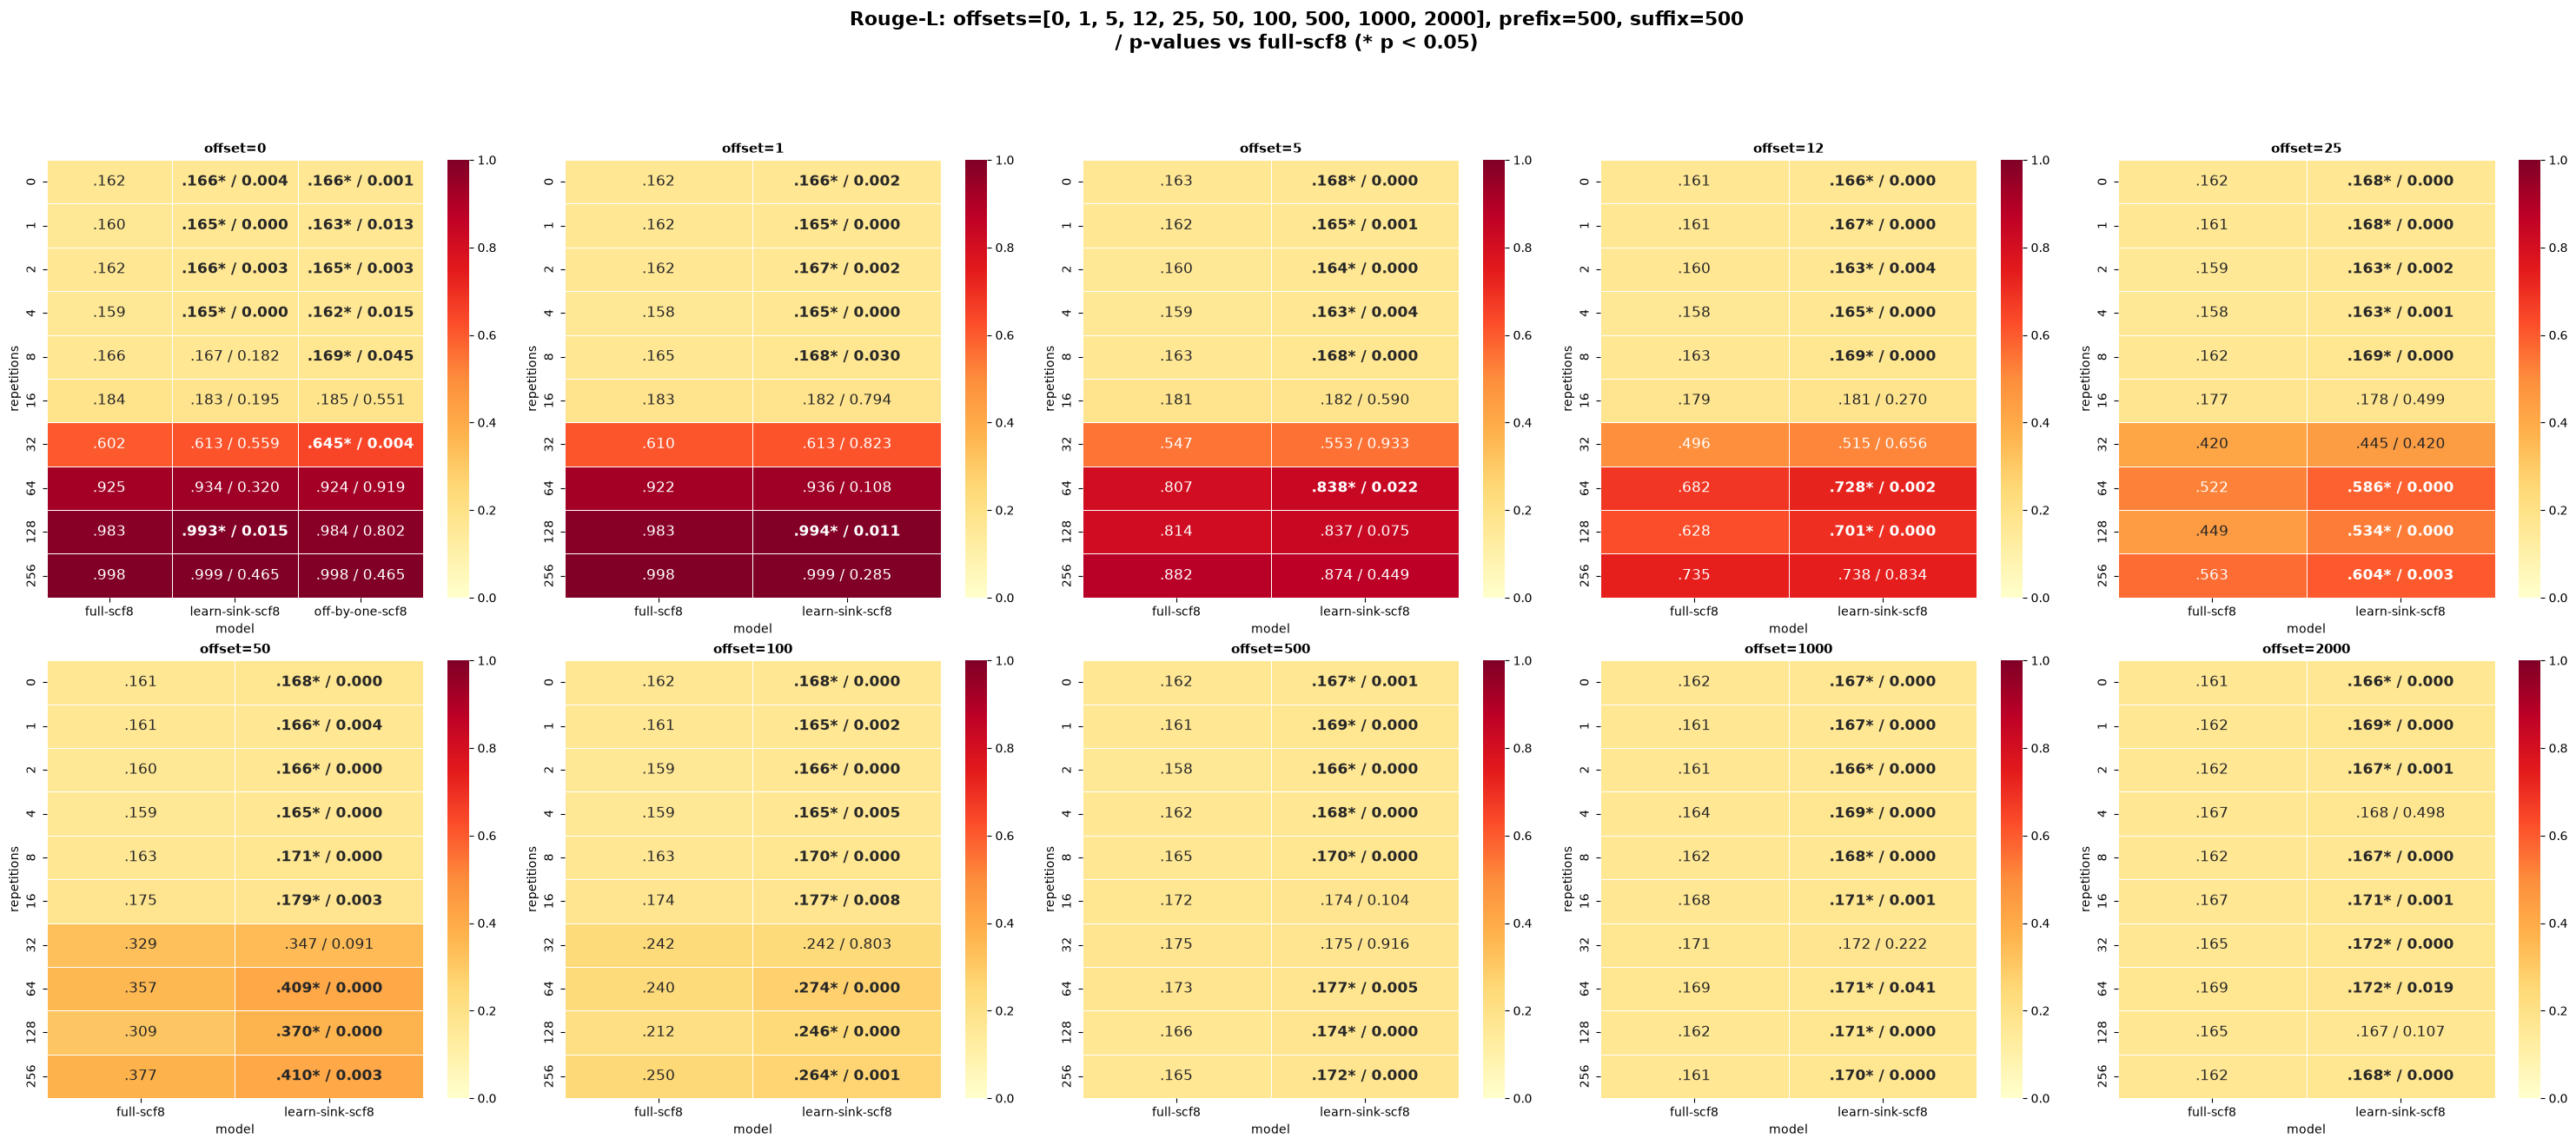

In [4]:
plot_models_heatmap_panel(
    results_grid, 'Rouge-L', models=MODELS, panels='offset', values=OFFSETS, fixed_prefix=500, fixed_suffix=500, ncols=5,
    reference='full-scf8',
)

#### Prefixes

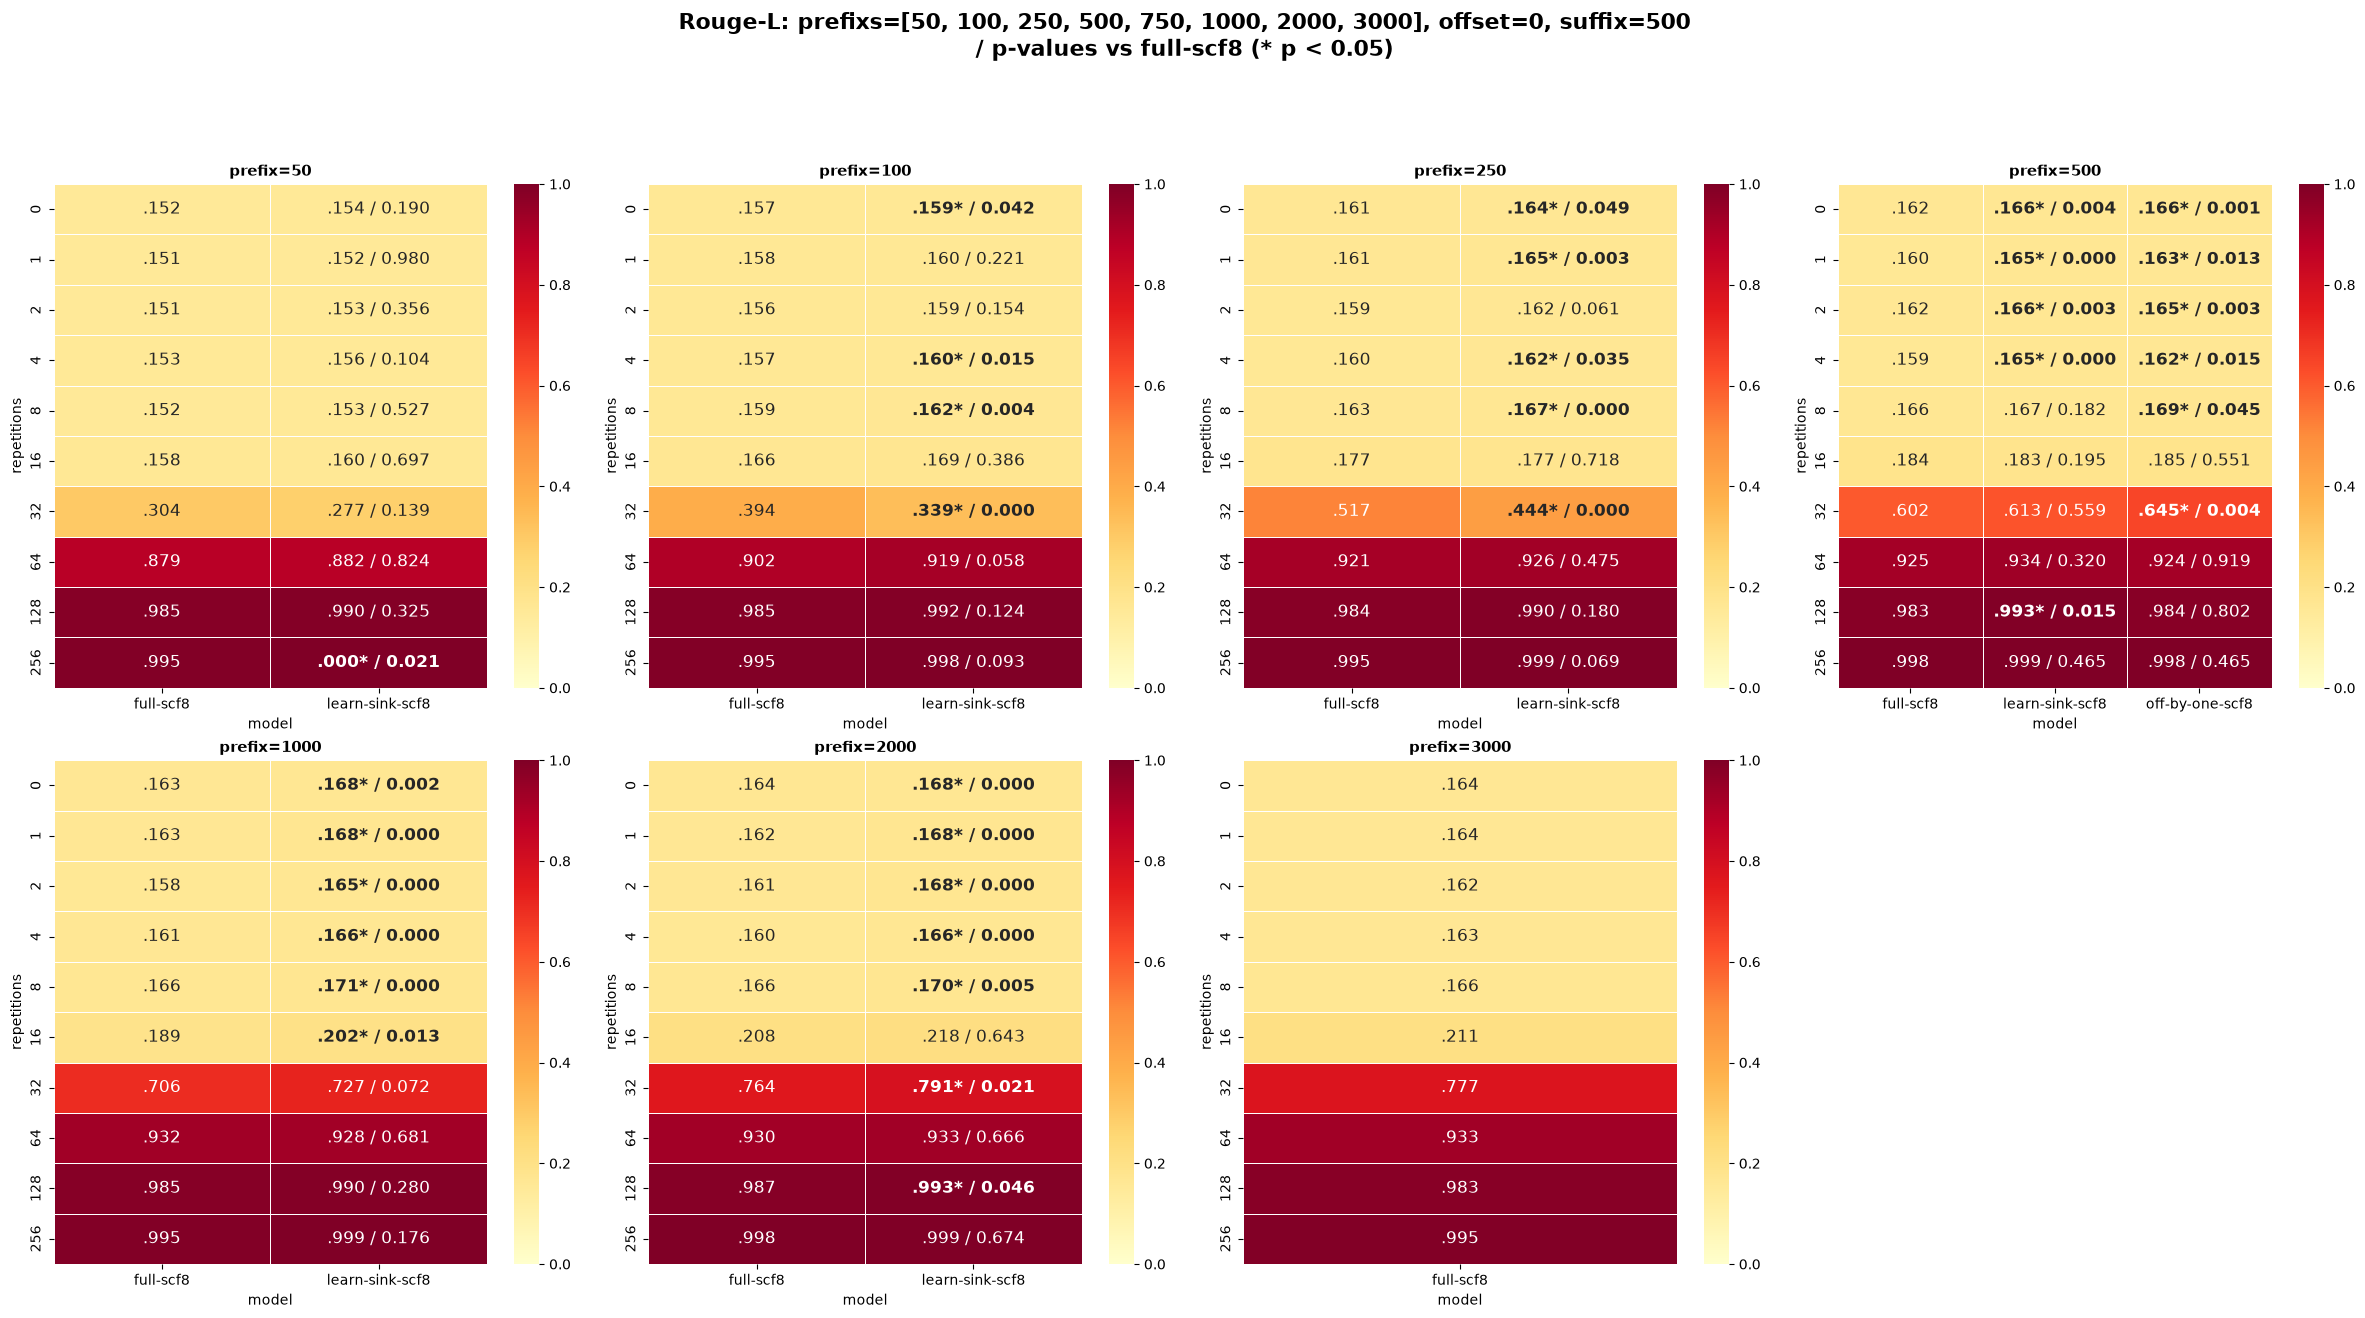

In [5]:
plot_models_heatmap_panel(
    results_grid, 'Rouge-L', models=MODELS, panels='prefix', values=PREFIXES, fixed_offset=0, fixed_suffix=500, ncols=4,
    reference='full-scf8',
)

## Scaling sink values

Off-by-one and learnable sink, grouped by metric/plot type instead of by model, so each one's off-by-one and learn-sink versions sit next to each other for direct comparison.

### Load memorization results

In [6]:
RESULTS_BASE = model_registry.MEM_RESULTS_DIR_OLD
OFFSET, PREFIX, SUFFIX = 0, 500, 500

# off-by-one has inference data up to sscale=32 (4/8/16/32 stored under the older nsinks)
OBO_SSCALES = (0, 0.25, 0.5, 0.75, 1, 1.5, 2, 4, 8, 16, 32)

# learn-sink only has inference data up to sscale=2
LEARN_SSCALES = (0.25, 0.5, 0.75, 1, 1.5, 2)

# adding the full model to compare against as a baseline
OBO_SINK_EXP_NAMES = {'full': model_registry.MODELS['full-scf8-scf1'],  **model_registry.sink_variant('off-by-one-scf8', sscales=OBO_SSCALES, results_base=RESULTS_BASE)}
LEARN_SINK_EXP_NAMES = {'full': model_registry.MODELS['full-scf8-scf1'], **model_registry.sink_variant('learn-sink-scf8')}

obo_sink_results = load_mem_results_by_name(OBO_SINK_EXP_NAMES, RESULTS_BASE,
                                            prefix=PREFIX, suffix=SUFFIX, offset=OFFSET)
learn_sink_results = load_mem_results_by_name(LEARN_SINK_EXP_NAMES, RESULTS_BASE,
                                              prefix=PREFIX, suffix=SUFFIX, offset=OFFSET)

Missing (not yet run): llama3-1b-full-attn-scf8-fineweb40B-gutenberg3B-scf1 with prefix=500, suffix=500, offset=0
Missing (not yet run): llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te215_sscale0-scf1 with prefix=500, suffix=500, offset=0
Missing (not yet run): llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te215_sscale0.25-scf1 with prefix=500, suffix=500, offset=0
Missing (not yet run): llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te215_sscale0.5-scf1 with prefix=500, suffix=500, offset=0
Missing (not yet run): llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te215_sscale0.75-scf1 with prefix=500, suffix=500, offset=0
Missing (not yet run): llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te215-scf1 with prefix=500, suffix=500, offset=0
Missing (not yet run): llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te215_sscale1.5-scf1 with prefix=500, suffix=500, offset=0
Missing (not yet run): llama3-1b-off-by-one-attn-scf8-fineweb40B-gutenberg3B-te2

### Trained sink values distribution: learnable sink only
Plotting original learned sink values (softmax_offset) before any scaling, on each layer x each head.
Read from `sink_scale_metadata.json`


Loaded from: learn-sink-scf8 sscale=0


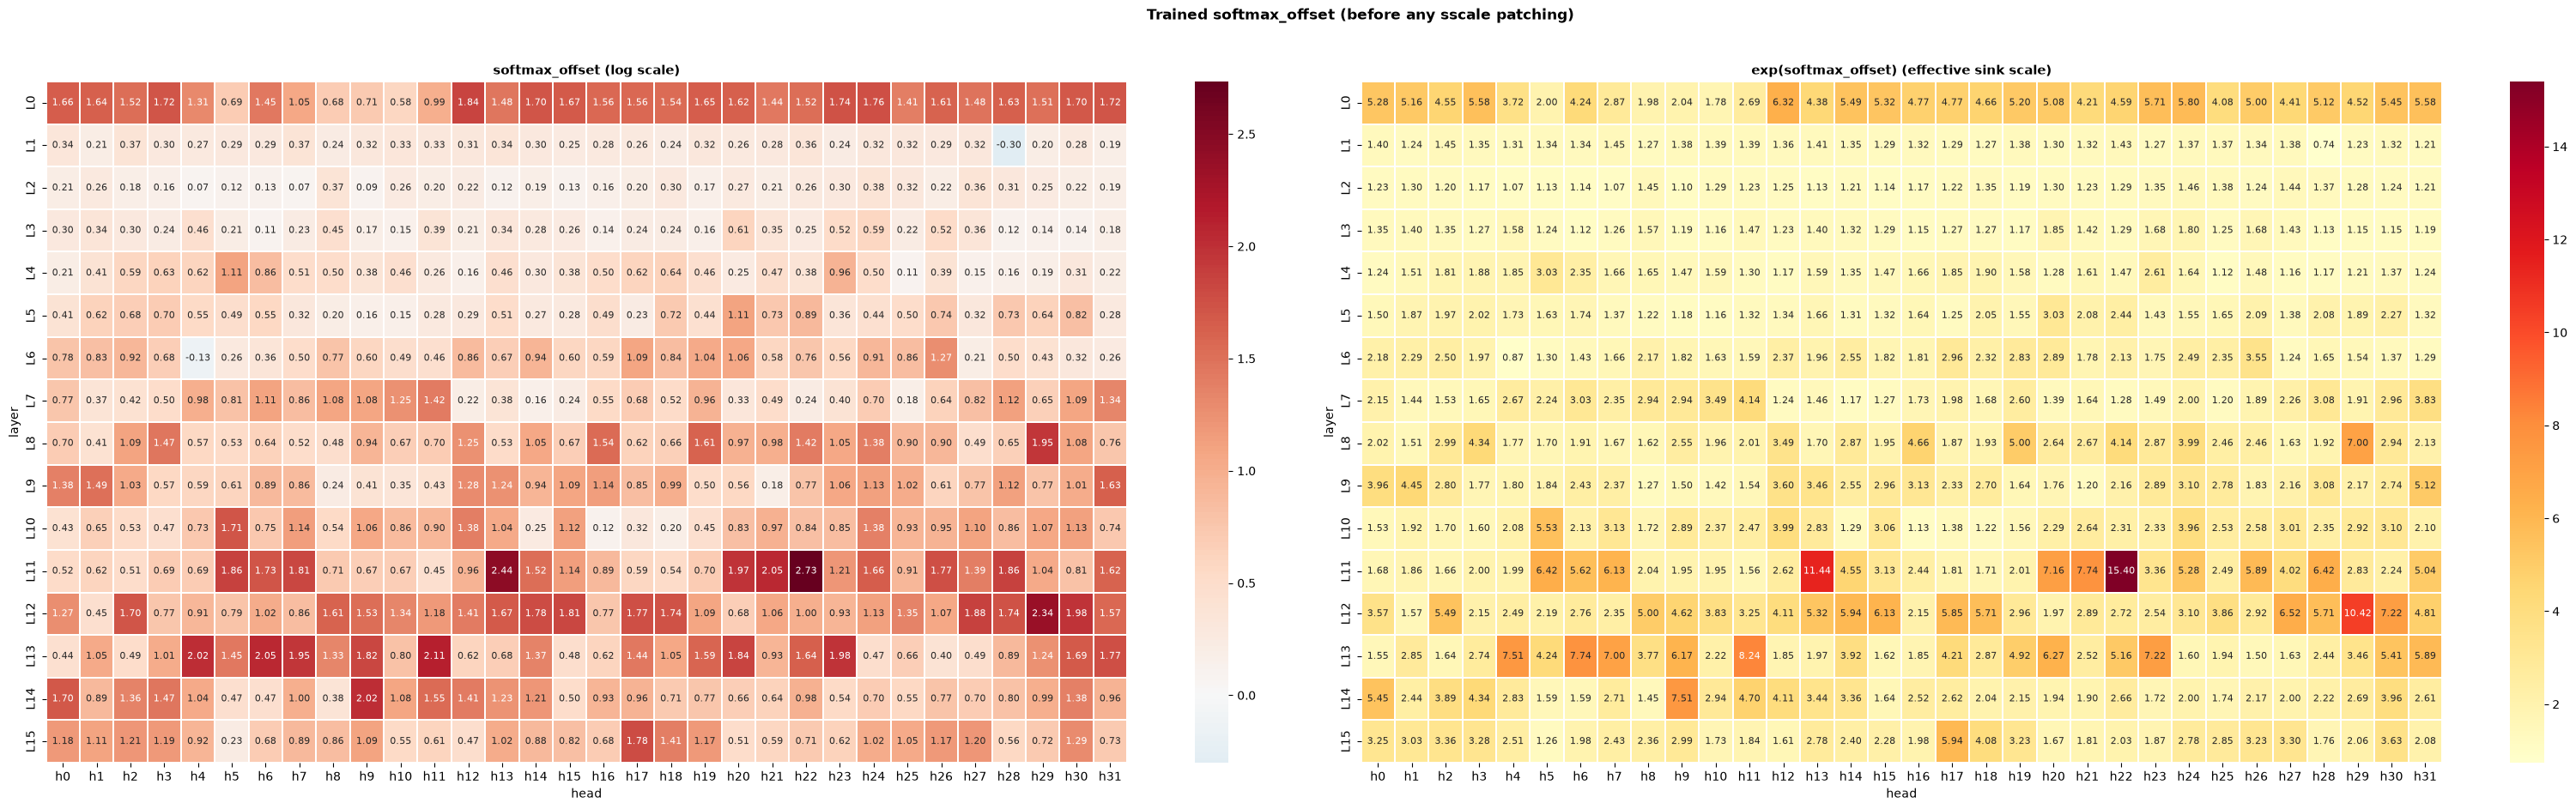

In [7]:
offsets, source_label = load_trained_sink_offsets(LEARN_SINK_EXP_NAMES, RESULTS_BASE)
if offsets is None:
    print('No sink_scale_metadata.json found - run at least one sscale experiment first.')
else:
    print(f'Loaded from: {source_label}')
    plot_trained_sink_offsets(offsets, source_label)

### Rouge-L

In [8]:
if obo_sink_results:
    plot_models_heatmap(obo_sink_results, 'Rouge-L', offset=OFFSET, prefix=PREFIX, suffix=SUFFIX, reference='full',
                       title='Rouge-L: off-by-one attn')
if learn_sink_results:
    plot_models_heatmap(learn_sink_results, 'Rouge-L', offset=OFFSET, prefix=PREFIX, suffix=SUFFIX, reference='full', fig_vscale=0.7, title='Rouge-L: learn-sink attn')

### PPL
Line plot (x = repetitions, one line per sink value) for perplexity.

In [9]:
if obo_sink_results:
    plot_sink_ppl(obo_sink_results, 'off-by-one', sscales=OBO_SSCALES, show_std=False,
                  prefix=PREFIX, suffix=SUFFIX, offset=OFFSET)

In [10]:
if learn_sink_results:
    plot_sink_ppl(learn_sink_results, 'learn-sink', sscales=LEARN_SSCALES, show_std=False,
                  prefix=PREFIX, suffix=SUFFIX, offset=OFFSET)

### TTR
Line plot (x = repetitions, one line per sink value) for type-to-token ratio.

In [11]:
if obo_sink_results:
    plot_sink_ttr(obo_sink_results, 'off-by-one', sscales=OBO_SSCALES, show_std=True,
                  prefix=PREFIX, suffix=SUFFIX, offset=OFFSET)

In [12]:
if learn_sink_results:
    plot_sink_ttr(learn_sink_results, 'learn-sink', sscales=LEARN_SSCALES, show_std=True,
                  prefix=PREFIX, suffix=SUFFIX, offset=OFFSET)

### Generation quality: perplexity & distinct-n

Perplexity of generated suffixes under Qwen2.5-1.5B (reference model independent of training), and token-level distinct-n diversity (unique n-grams / total). Both are loaded from the JSON files produced by `compute_generation_quality.py`; experiments without a JSON are silently skipped.

In [13]:
obo_sink_quality = load_generation_quality(OBO_SINK_EXP_NAMES, RESULTS_BASE, OFFSET, PREFIX, SUFFIX)
learn_sink_quality = load_generation_quality(LEARN_SINK_EXP_NAMES, RESULTS_BASE, OFFSET, PREFIX, SUFFIX)

print(f"off-by-one:  {list(obo_sink_quality.keys())}")
print(f"learn-sink:  {list(learn_sink_quality.keys())}")

off-by-one:  ['full', 'off-by-one-scf8 sscale=0', 'off-by-one-scf8 sscale=0.25', 'off-by-one-scf8 sscale=0.5', 'off-by-one-scf8 sscale=0.75', 'off-by-one-scf8 sscale=1 (default)', 'off-by-one-scf8 sscale=1.5', 'off-by-one-scf8 sscale=2']
learn-sink:  ['full', 'learn-sink-scf8 sscale=0', 'learn-sink-scf8 sscale=0.25', 'learn-sink-scf8 sscale=0.5', 'learn-sink-scf8 sscale=0.75', 'learn-sink-scf8 sscale=1 (default)', 'learn-sink-scf8 sscale=1.5', 'learn-sink-scf8 sscale=2']


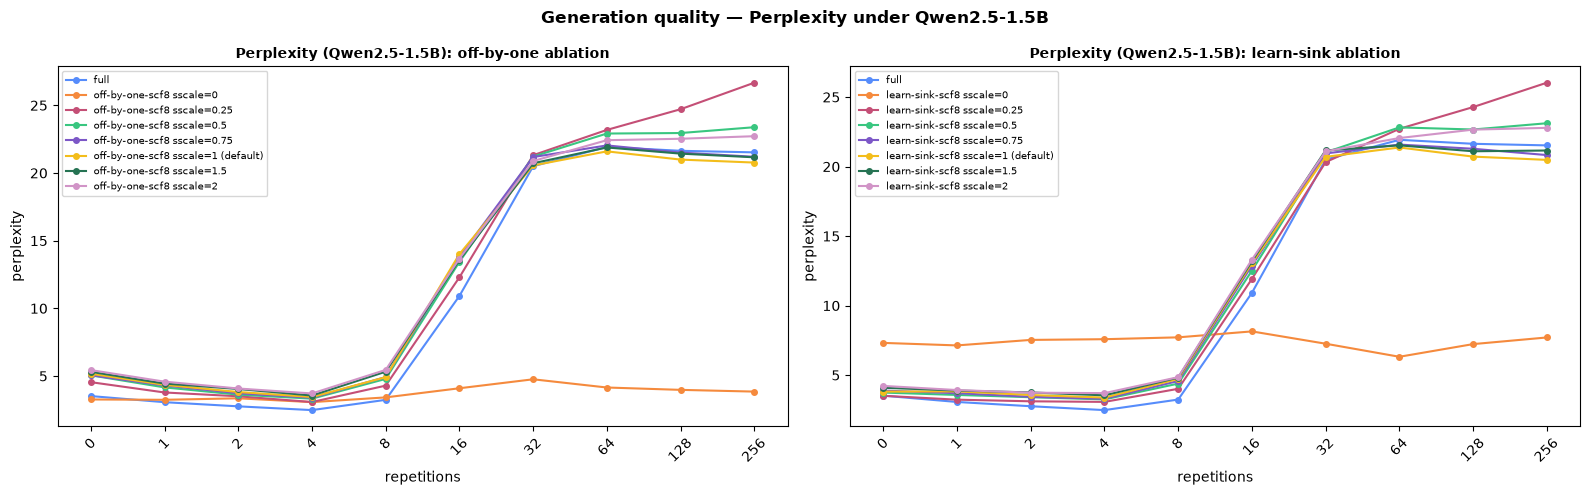

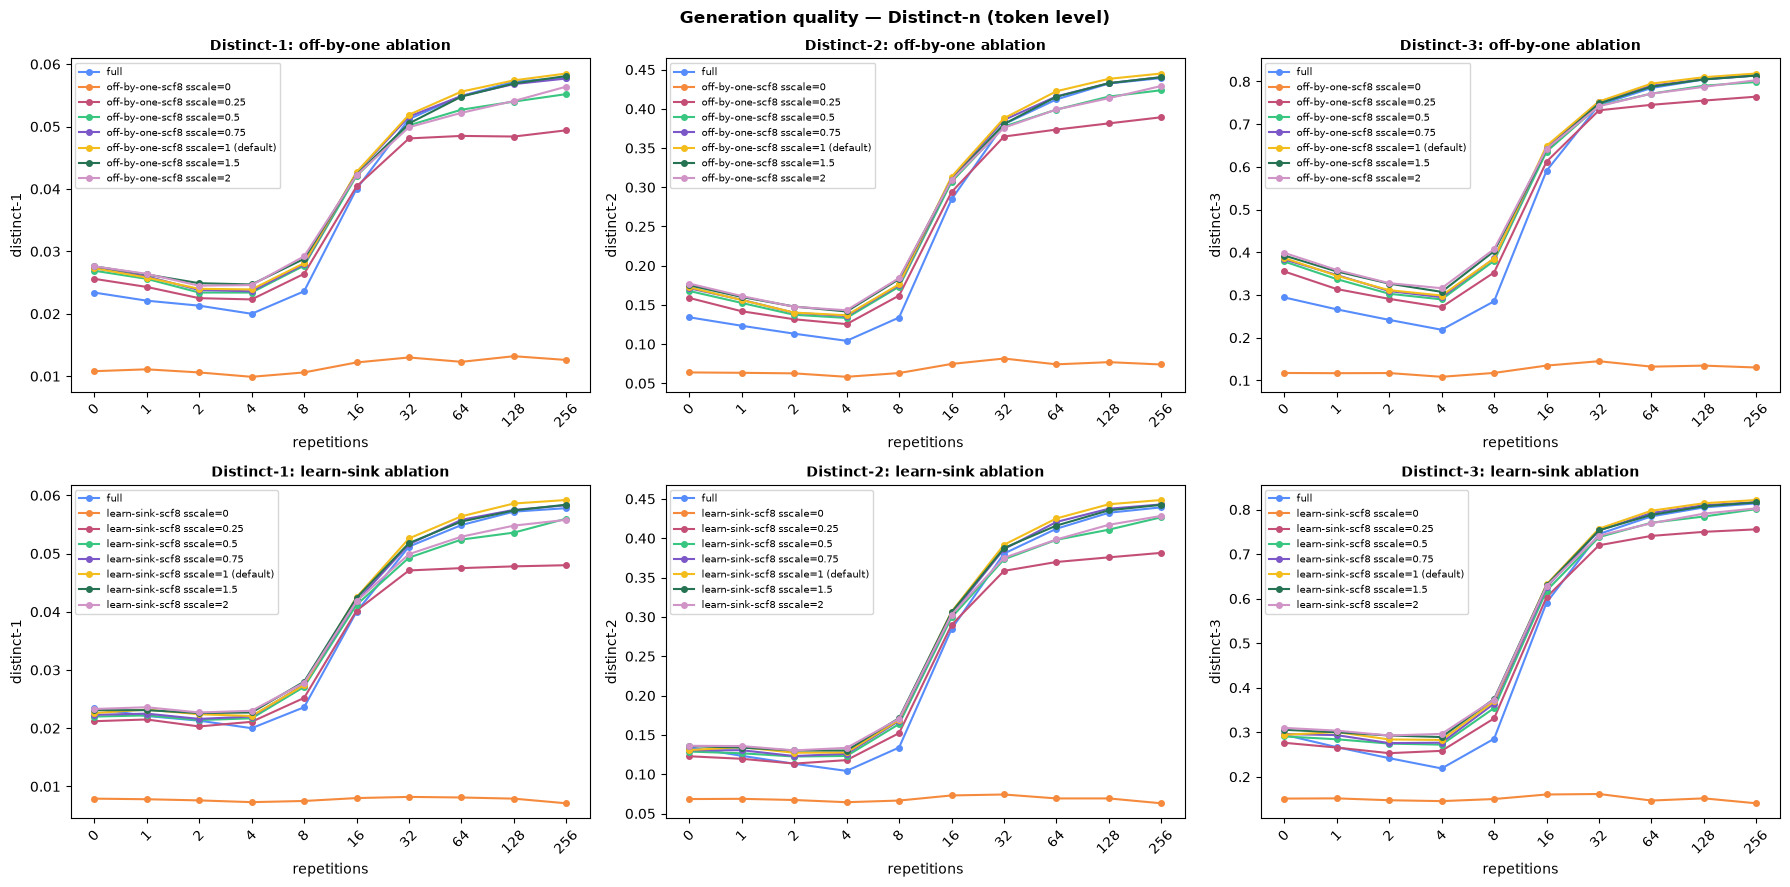

In [14]:
QUALITY_SETS = [
    ('off-by-one ablation', obo_sink_quality),
    ('learn-sink ablation', learn_sink_quality),
]

plot_generation_quality(QUALITY_SETS)

## Inference correctness

Comparing tp=1 (unfused attn), tp=4 (unfused attn), and tp=1 (fused attn) for sink /
off-by-one, to make sure each is implemented correctly.

In [15]:
REPS = [0]

# tp=1 (unfused): capped at ~12k. tp=4 (unfused): reaches 20k. tp=1 (fused): full length.
# Configs are compared in order, adjacent pair by adjacent pair, so each step isolates one
# variable (TP degree, then fused/unfused) rather than both changing at once.
TP_FUSION_CONFIGS = {
    'tp=1 (unfused)': 'all_samples_12288_tokens',
    'tp=4 (unfused)': 'all_samples_20480_tokens_tp4',
    'tp=1 (fused)': model_registry.LONG_INFERENCE_CONFIG,
}

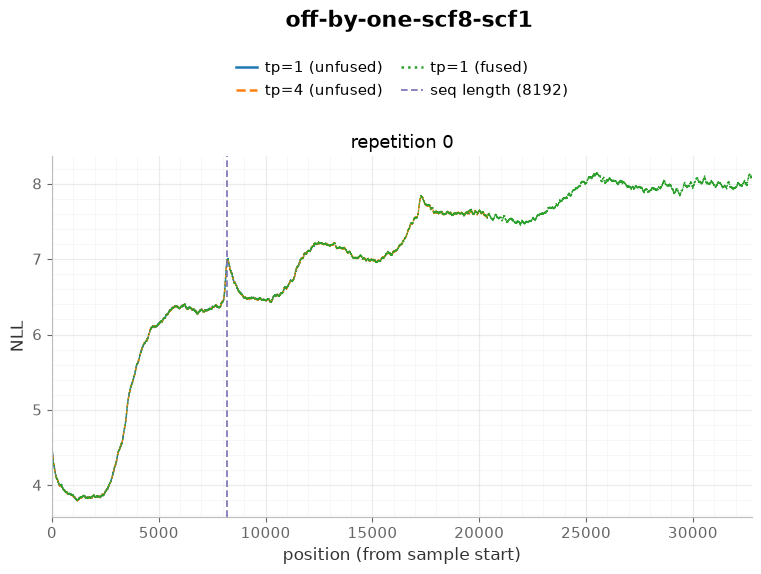

tp=1 (unfused) vs tp=4 (unfused)
   rep  shared_pos   max_abs    max_%   mean_abs   mean_%
     0       12287  1.24e-02    0.22%   2.24e-03    0.04%
  worst mean diff over all reps: 0.04% of typical loss  [OK]

tp=4 (unfused) vs tp=1 (fused)
   rep  shared_pos   max_abs    max_%   mean_abs   mean_%
     0       20479  1.31e-02    0.21%   2.15e-03    0.03%
  worst mean diff over all reps: 0.03% of typical loss  [OK]



In [16]:

plot_sink_nll_comparison('off-by-one-scf8-scf1', TP_FUSION_CONFIGS, REPS, xmax=4 * SEQ_LEN)

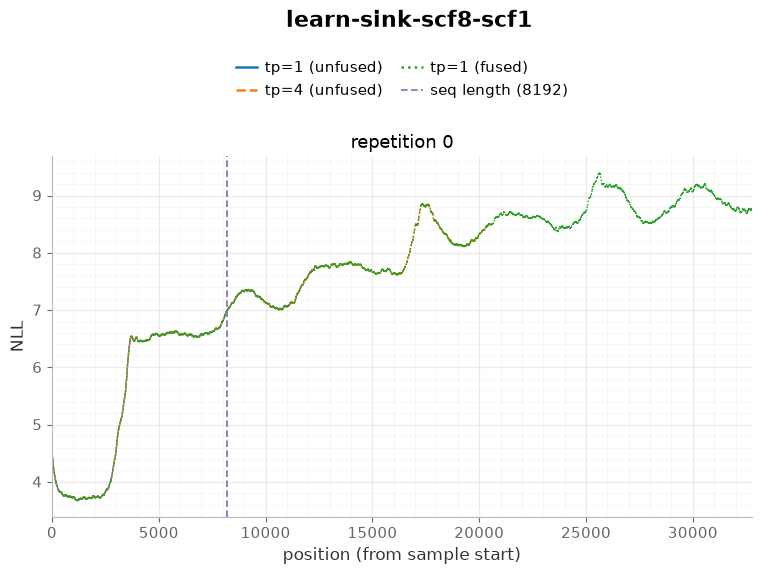

tp=1 (unfused) vs tp=4 (unfused)
   rep  shared_pos   max_abs    max_%   mean_abs   mean_%
     0       12287  1.22e-02    0.20%   2.13e-03    0.04%
  worst mean diff over all reps: 0.04% of typical loss  [OK]

tp=4 (unfused) vs tp=1 (fused)
   rep  shared_pos   max_abs    max_%   mean_abs   mean_%
     0       20479  1.33e-02    0.19%   2.19e-03    0.03%
  worst mean diff over all reps: 0.03% of typical loss  [OK]



In [17]:
plot_sink_nll_comparison('learn-sink-scf8-scf1', TP_FUSION_CONFIGS, REPS, xmax=4 * SEQ_LEN)